#Objetivo del ejercicio
Predecir usando las features de Spotify mediante una red neuronal con Keras, popularidad de las canciones




In [1]:
# ============================================
#  CARGA + LIMPIEZA + INGENIERÍA DE DATOS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Cargar dataset
try:
    df = pd.read_csv('datos_spotify (2).csv', encoding='utf-8')
except:
    df = pd.read_csv('datos_spotify (2).csv', encoding='latin1')

df = df.copy().drop_duplicates()

# --- DEFINICIÓN DE COLUMNAS ---
# Definimos qué es numérico y qué es categórico
cols_numeric = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms'
]
col_target = 'track_popularity'
cols_categorical = ['playlist_genre']

# --- LIMPIEZA E IMPUTACIÓN  ---
# 1. Convertir a numérico y manejar fechas
for col in cols_numeric + [col_target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], errors='coerce')
df['release_year'] = df['track_album_release_date'].dt.year

# 2. Imputación con la mediana
cols_to_impute = cols_numeric + ['release_year']
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

# 3. Eliminar filas donde el target sea nulo
df = df.dropna(subset=[col_target])

# ---  PREPARACIÓN PARA LA RED NEURONAL ---
# Separamos las características (X) y el objetivo (y)
X_num = df[cols_numeric + ['release_year']]
X_cat = df[cols_categorical]
y = df[col_target]

# One-Hot Encoding para los géneros
encoder = OneHotEncoder(sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_cat)

# Un solo conjunto de datos
X_final = np.hstack([X_num.values, X_cat_encoded])

print(f"Dataset listo.")
print(f"Variables numéricas: {len(cols_numeric) + 1}")
print(f"Variables categóricas (One-Hot): {X_cat_encoded.shape[1]}")
print(f"Total de features para la red: {X_final.shape[1]}")

Dataset listo.
Variables numéricas: 13
Variables categóricas (One-Hot): 6
Total de features para la red: 19


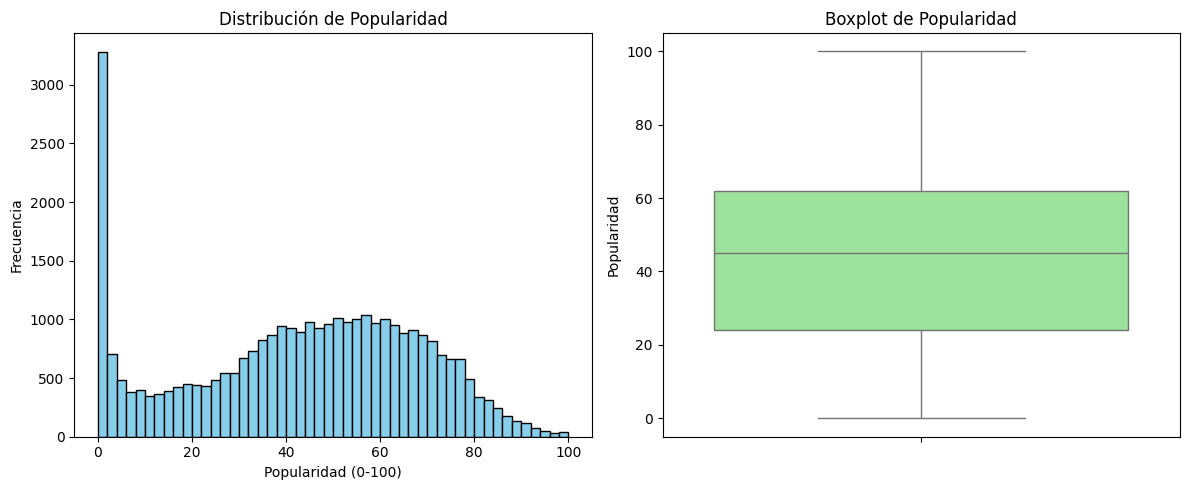

/tmp/ipykernel_9519/3960064716.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='playlist_genre', y='track_popularity', data=df, palette='viridis', ci=None)
/tmp/ipykernel_9519/3960064716.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='playlist_genre', y='track_popularity', data=df, palette='viridis', ci=None)


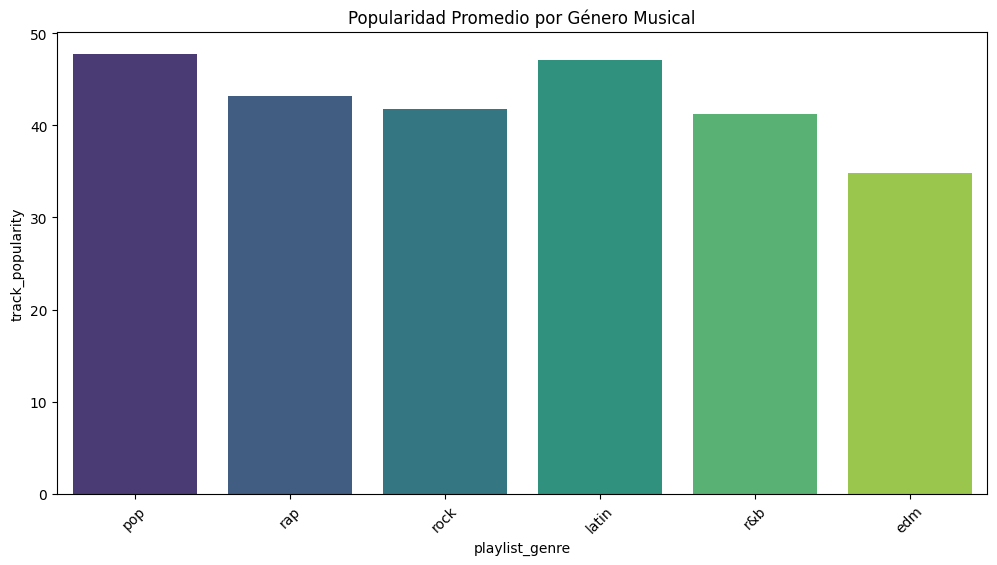

In [2]:
# ============================================
#  ANÁLISIS EXPLORATORIO (EDA)
# ============================================

# 1. Distribución de la variable objetivo (Popularidad)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['track_popularity'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribución de Popularidad')
plt.xlabel('Popularidad (0-100)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['track_popularity'], color='lightgreen')
plt.title('Boxplot de Popularidad')
plt.ylabel('Popularidad')
plt.tight_layout()
plt.show()

# 2. Análisis de Popularidad por Género
plt.figure(figsize=(12, 6))
sns.barplot(x='playlist_genre', y='track_popularity', data=df, palette='viridis', ci=None)
plt.title('Popularidad Promedio por Género Musical')
plt.xticks(rotation=45)
plt.show()


Correlación de variables numéricas con popularidad:
track_popularity    1.000000
acousticness        0.085159
danceability        0.064748
release_year        0.059441
loudness            0.057687
valence             0.033231
mode                0.010637
speechiness         0.006819
key                -0.000650
tempo              -0.005378
liveness           -0.054584
energy             -0.109112
duration_ms        -0.143682
instrumentalness   -0.149872
Name: track_popularity, dtype: float64


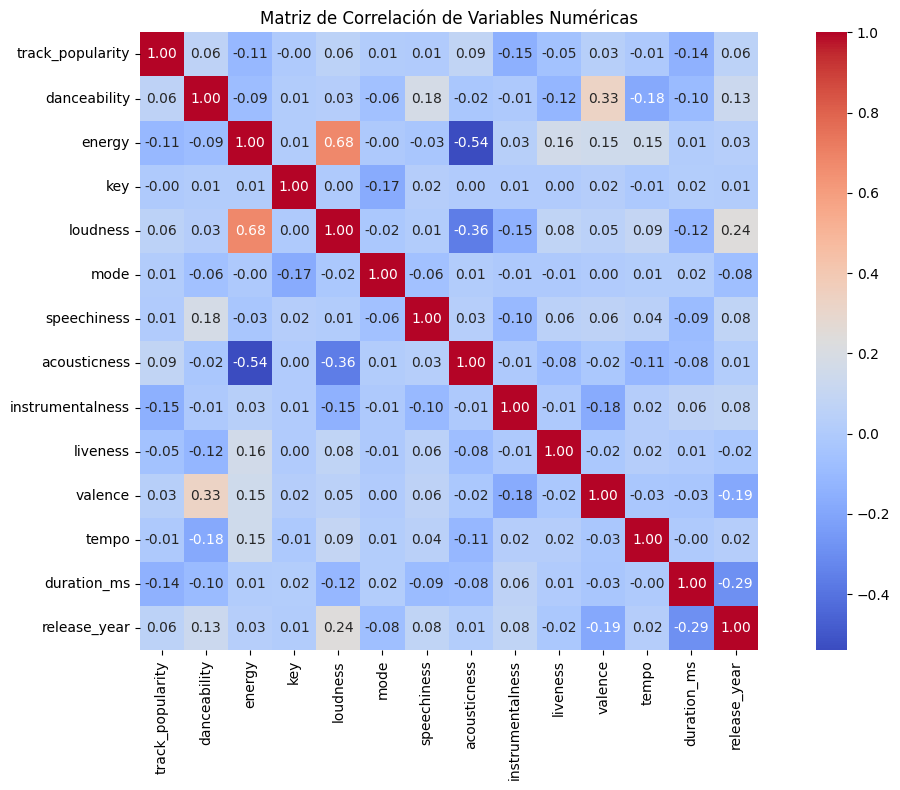

In [3]:
# ============================================
#  ANÁLISIS EXPLORATORIO (EDA)
# ============================================

# 3. Correlación de variables numéricas (Incluyendo el año de lanzamiento)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_popularity = (
    df[numeric_cols]
    .corr()['track_popularity']
    .sort_values(ascending=False)
)

print(f"\nCorrelación de variables numéricas con popularidad:\n{corr_with_popularity}")

# 4. Matriz de Correlación Visual (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.tight_layout()
plt.show()

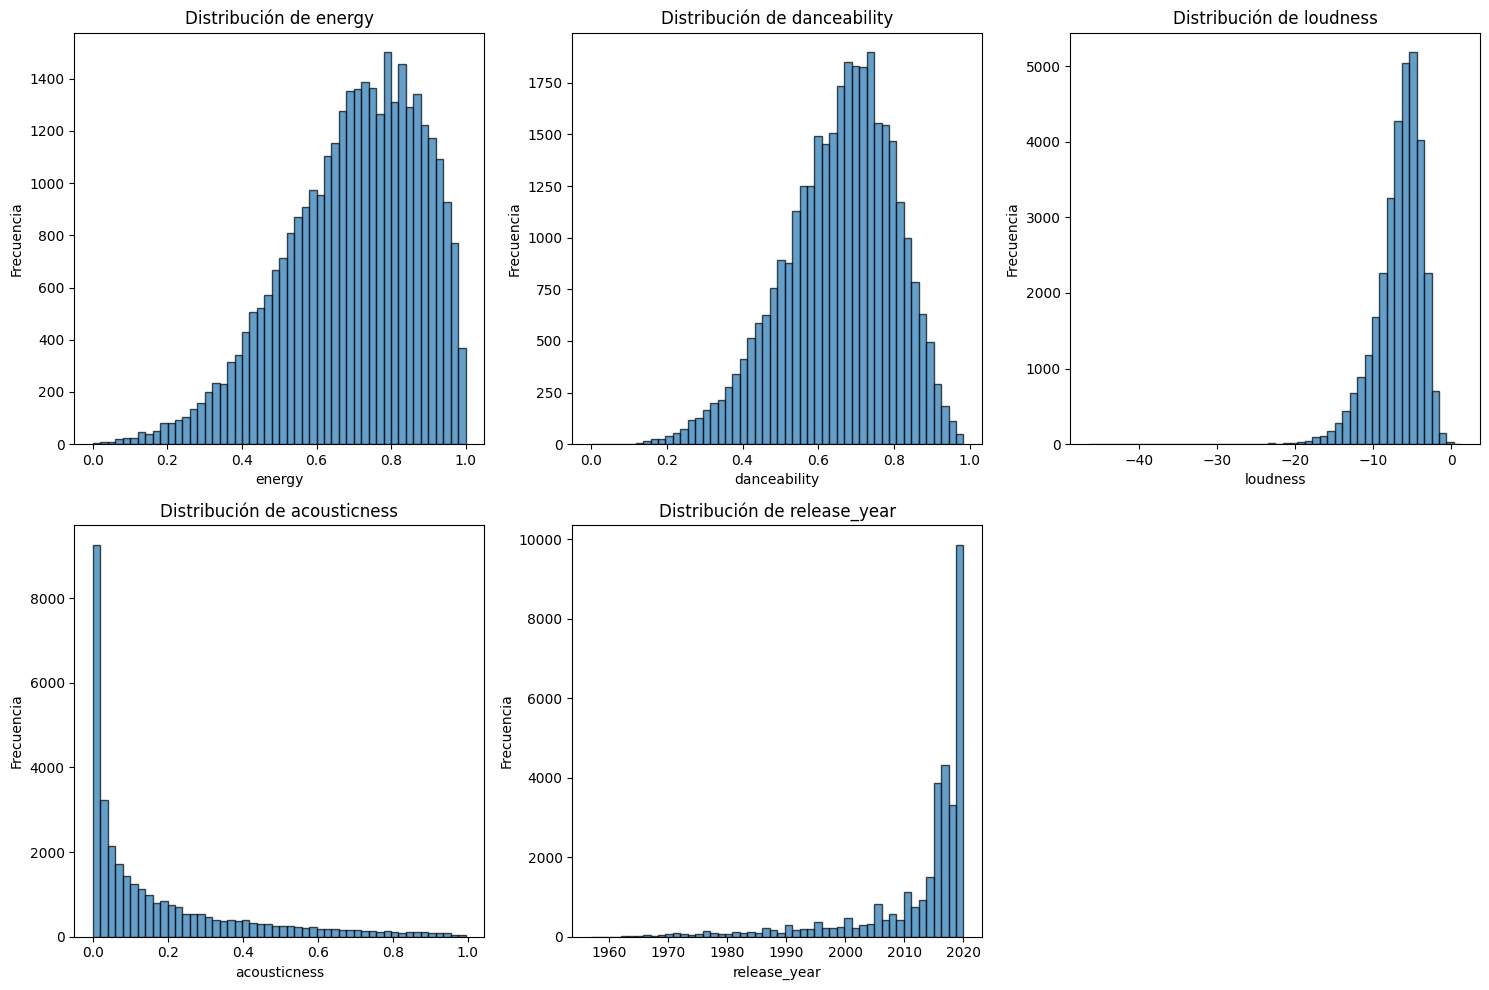

In [4]:
# ============================================
# ANÁLISIS DE DISTRIBUCIÓN DE FEATURES
# ============================================

# Características más correlacionadas con popularidad
top_features = ['energy', 'danceability', 'loudness', 'acousticness', 'release_year']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_features, 1):
    plt.subplot(2, 3, i)
    plt.hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [5]:
# ============================================
#  PREPROCESAMIENTO DE DATOS
# ============================================

# 1. Definición de columnas a eliminar
features_to_drop = [
    'track_id',
    'track_name',
    'track_artist',
    'track_album_name',
    'track_album_id',
    'track_album_release_date',
    'playlist_name',
    'playlist_id',
    'playlist_subgenre', # Usaremos el género principal para no saturar de columnas
    'track_popularity'   # Target
]

# 2. Separar Target (y) y Características (X)
X_raw = df.drop(columns=features_to_drop, errors='ignore')
y = df['track_popularity']

# ---  TRATAMIENTO DE GÉNEROS ---
# En lugar de borrar todo lo que no sea número, transformamos el género en columnas 0/1
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Ajustamos a la columna 'playlist_genre'
genres_encoded = encoder.fit_transform(X_raw[['playlist_genre']])
genres_df = pd.DataFrame(genres_encoded, columns=encoder.get_feature_names_out(['playlist_genre']), index=X_raw.index)

# 3. Quedarse con numéricas + Géneros codificados
X_numeric = X_raw.select_dtypes(include=[np.number])
X = pd.concat([X_numeric, genres_df], axis=1)

print(f"\nFeatures finales seleccionadas: {X.columns.tolist()}")
print(f"Shape X: {X.shape}, Shape y: {y.shape}")

# 4. SPLIT: Train (70%) / Val (15%) / Test (15%)
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

print(f"\nConjuntos creados:")
print(f" - Train set: {X_train.shape}")
print(f" - Validation set: {X_val.shape}")
print(f" - Test set: {X_test.shape}")

# 5. NORMALIZACIÓN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# El scaler solo aprende (fit) de Train para evitar Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Datos preparados y escalados para el modelo")


Features finales seleccionadas: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'release_year', 'playlist_genre_edm', 'playlist_genre_latin', 'playlist_genre_pop', 'playlist_genre_r&b', 'playlist_genre_rap', 'playlist_genre_rock']
Shape X: (32833, 19), Shape y: (32833,)

Conjuntos creados:
 - Train set: (22982, 19)
 - Validation set: (4926, 19)
 - Test set: (4925, 19)

✅ Datos preparados y escalados para el modelo


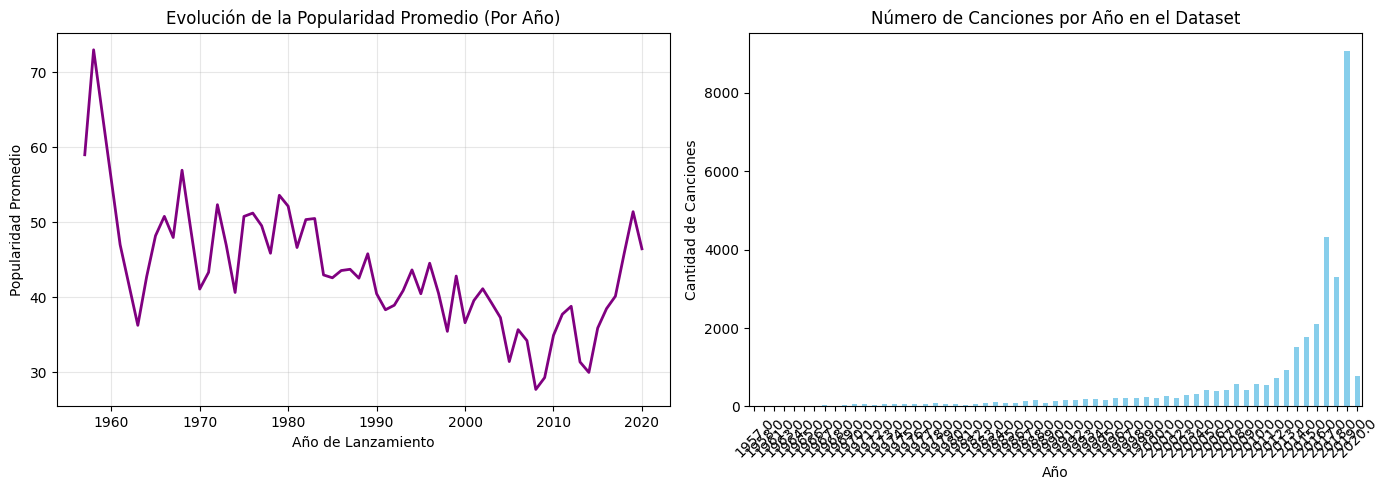

In [6]:
# ============================================
# EVOLUCIÓN DE LA POPULARIDAD EN EL TIEMPO
# ============================================

# Popularidad promedio por año de lanzamiento
popularity_by_year = df.groupby('release_year')['track_popularity'].mean()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(popularity_by_year.index, popularity_by_year.values, linewidth=2, color='purple')
plt.title('Evolución de la Popularidad Promedio (Por Año)')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Popularidad Promedio')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
df.groupby('release_year').size().plot(kind='bar', color='skyblue')
plt.title('Número de Canciones por Año en el Dataset')
plt.xlabel('Año')
plt.ylabel('Cantidad de Canciones')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# ============================================
#  ARQUITECTURA, COMPILACIÓN Y CALLBACKS
# ============================================

import tensorflow as tf

# 1. DEFINICIÓN DE LA ARQUITECTURA
model = tf.keras.Sequential([
    # Capa de entrada
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),

    # Bloque 1
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    # Bloque 2
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    # Bloque 3
    tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    # Capa de salida para regresión
    tf.keras.layers.Dense(1)
])

# 2. COMPILACIÓN DEL MODELO
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# 3. CONFIGURACIÓN DE CALLBACKS
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'mejor_modelo_spotify.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Mostrar resumen y confirmar
model.summary()
print("\n Red Neuronal lista. El alias 'tf' ha sido configurado correctamente.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,377 (52.25 KB)

 Non-trainable params: 448 (1.75 KB)


 Red Neuronal lista. El alias 'tf' ha sido configurado correctamente.


In [8]:
# ============================================
#  ENTRENAMIENTO CON VALIDACIÓN
# ============================================

print("\\n" + "="*70)
print("ENTRENANDO MODELO CON VALIDACIÓN DE OVERFITTING")
print("="*70)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"\\n Entrenamiento completado en {len(history.history['loss'])} epochs")


\n======================================================================
ENTRENANDO MODELO CON VALIDACIÓN DE OVERFITTING
Epoch 1/200
704/719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2128.3234 - mae: 39.7485
Epoch 1: val_loss improved from None to 797.90796, saving model to mejor_modelo_spotify.keras

Epoch 1: finished saving model to mejor_modelo_spotify.keras
719/719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 1722.4023 - mae: 35.3107 - val_loss: 797.9080 - val_mae: 24.3254 - learning_rate: 0.0010
Epoch 2/200
708/719 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 694.4366 - mae: 22.3395
Epoch 2: val_loss improved from 797.90796 to 534.19598, saving model to mejor_modelo_spotify.keras

Epoch 2: finished saving model to mejor_modelo_spotify.keras
719/719 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 621.5812 - mae: 20.9610 - val_loss: 534.1960 - val_mae: 19.2693 - learning_rate: 0.0010
Epoch 3/200
716/719 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 573.2415 - mae: 19.9493
Epoch 3: val_loss improved from

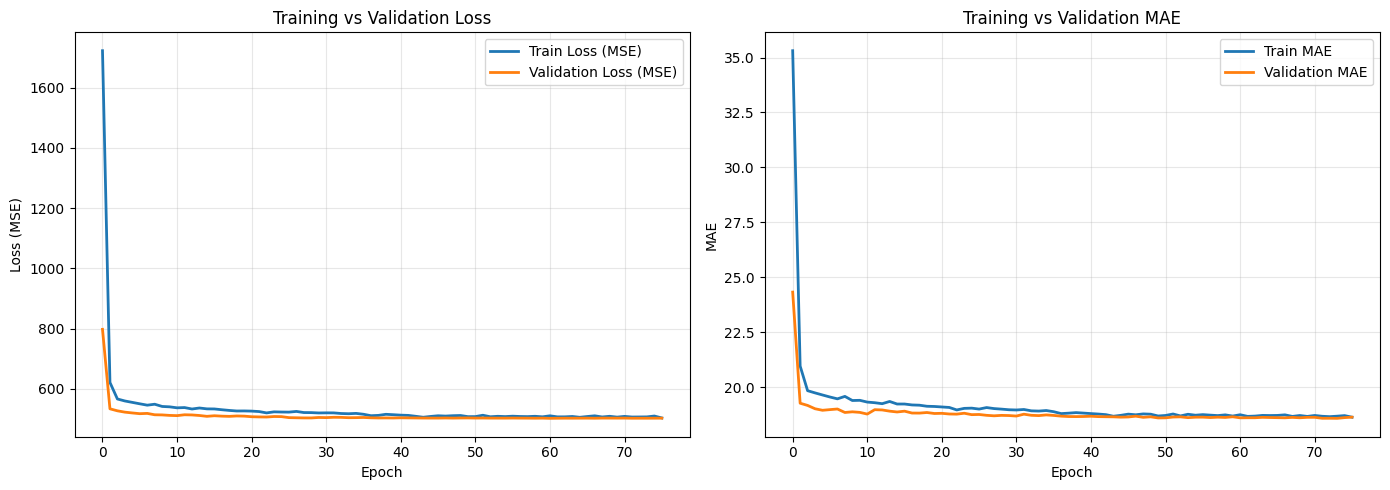


DIAGNÓSTICO TÉCNICO DEL APRENDIZAJE
MAE Entrenamiento final: 18.6339
MAE Validación final:    18.6346
Diferencia (Gap):        0.0008
 EL MODELO GENERALIZA BIEN: El error en datos nuevos es similar al de entrenamiento.


In [9]:
# ============================================
#  GRÁFICAS DE VALIDACIÓN (DETECCIÓN OVERFITTING)
# ============================================

import matplotlib.pyplot as plt

# GRÁFICA 1: Loss vs Val_Loss
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# GRÁFICA 2: MAE vs Val_MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_validation.png', dpi=300)
plt.show()

# --- INTERPRETACIÓN AUTOMÁTICA  ---
final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]
mae_diff = abs(final_val_mae - final_train_mae)

print("\n" + "="*70)
print("DIAGNÓSTICO TÉCNICO DEL APRENDIZAJE")
print("="*70)
print(f"MAE Entrenamiento final: {final_train_mae:.4f}")
print(f"MAE Validación final:    {final_val_mae:.4f}")
print(f"Diferencia (Gap):        {mae_diff:.4f}")

# Evaluación de la generalización
if mae_diff <= (final_train_mae * 0.15):
    print(" EL MODELO GENERALIZA BIEN: El error en datos nuevos es similar al de entrenamiento.")
elif mae_diff <= (final_train_mae * 0.30):
    print(" OVERFITTING MODERADO: La red empieza a memorizar, pero los resultados son aceptables.")
else:
    print(" OVERFITTING DETECTADO: La red ha memorizado el ruido. Revisa el Dropout.")

print("="*70)

In [10]:
# ============================================
#  EVALUACIÓN FINAL EN EL TEST SET
# ============================================

print("\n" + "="*70)
print("EVALUACIÓN FINAL DEL RENDIMIENTO")
print("="*70)

# 1. Cargar el mejor modelo guardado

try:
    best_model = tf.keras.models.load_model('mejor_modelo_spotify.keras')
except:
    best_model = model # Si el archivo no existe, usamos el modelo en memoria
    print(" No se encontró el archivo .keras, usando el modelo actual en memoria.")

# 2. Generar Predicciones
y_train_pred = best_model.predict(X_train_scaled).flatten()
y_val_pred = best_model.predict(X_val_scaled).flatten()
y_test_pred = best_model.predict(X_test_scaled).flatten()

# 3. Función de métricas
def evaluate_predictions(y_true, y_pred, dataset_name):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name}:")
    print(f"  MAE:  {mae:.4f} (Error promedio en puntos de popularidad)")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f} (Varianza explicada por el modelo)")

    return {'mae': mae, 'rmse': rmse, 'r2': r2}

# Ejecución de evaluación
train_metrics = evaluate_predictions(y_train, y_train_pred, "TRAIN SET")
val_metrics = evaluate_predictions(y_val, y_val_pred, "VALIDATION SET")
test_metrics = evaluate_predictions(y_test, y_test_pred, "TEST SET")

# 4. Tabla comparativa final
metrics_comparison = pd.DataFrame({
    'Entrenamiento': [train_metrics['mae'], train_metrics['rmse'], train_metrics['r2']],
    'Validación': [val_metrics['mae'], val_metrics['rmse'], val_metrics['r2']],
    'Test': [test_metrics['mae'], test_metrics['rmse'], test_metrics['r2']]
}, index=['MAE (Menor es mejor)', 'RMSE (Menor es mejor)', 'R² (Mayor es mejor)'])

print("\n--- RESUMEN DE MÉTRICAS ---")
print(metrics_comparison)


EVALUACIÓN FINAL DEL RENDIMIENTO
719/719 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

TRAIN SET:
  MAE:  17.9206 (Error promedio en puntos de popularidad)
  RMSE: 21.6087
  R²:   0.2539 (Varianza explicada por el modelo)

VALIDATION SET:
  MAE:  18.6043 (Error promedio en puntos de popularidad)
  RMSE: 22.4185
  R²:   0.2014 (Varianza explicada por el modelo)

TEST SET:
  MAE:  18.4523 (Error promedio en puntos de popularidad)
  RMSE: 22.1437
  R²:   0.1977 (Varianza explicada por el modelo)

--- RESUMEN DE MÉTRICAS ---
                       Entrenamiento  Validación       Test
MAE (Menor es mejor)       17.920565   18.604288  18.452301
RMSE (Menor es mejor)      21.608726   22.418540  22.143675
R² (Mayor es mejor)         0.253902    0.201427   0.197651


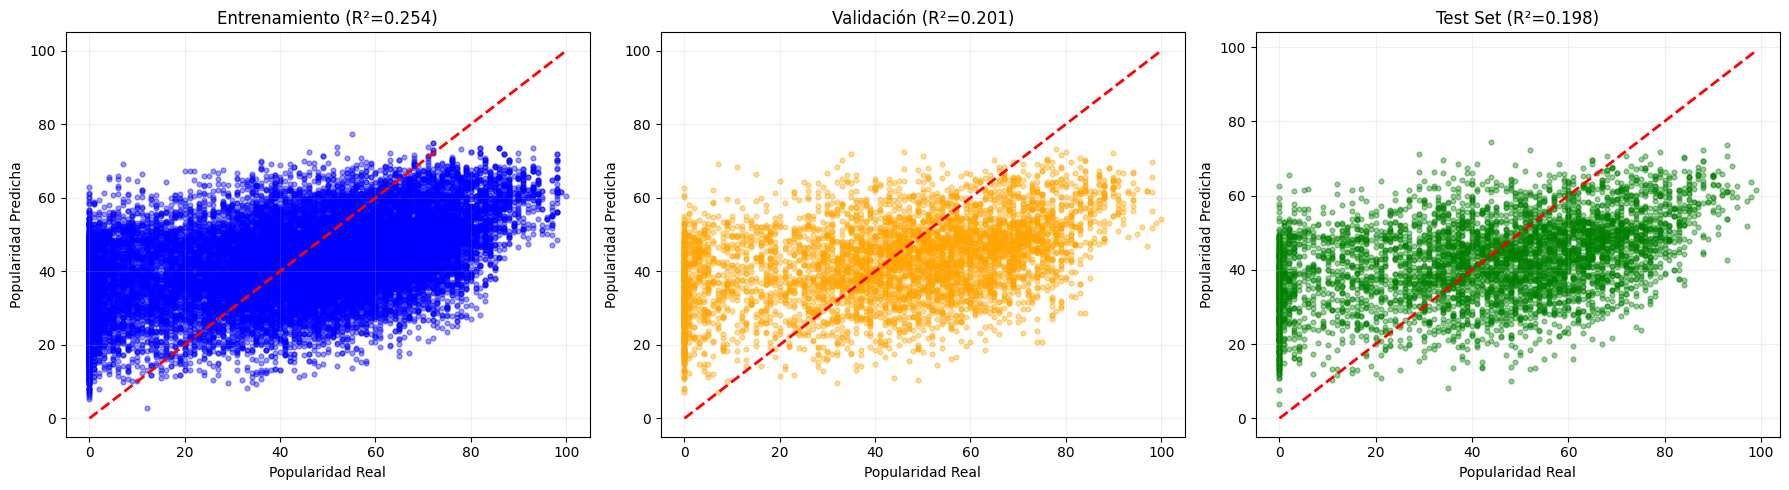

In [11]:
# ============================================
#  GRÁFICAS DE PREDICCIONES (COMPARATIVA FINAL)
# ============================================

plt.figure(figsize=(18, 5))

# Gráfica 1: Train Set - ¿Qué tanto aprendió de los datos conocidos?
plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.4, s=12, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title(f'Entrenamiento (R²={train_metrics["r2"]:.3f})')
plt.grid(True, alpha=0.2)

# Gráfica 2: Validation Set - ¿Cómo se ajusta durante el proceso?
plt.subplot(1, 3, 2)
plt.scatter(y_val, y_val_pred, alpha=0.4, s=12, color='orange')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title(f'Validación (R²={val_metrics["r2"]:.3f})')
plt.grid(True, alpha=0.2)

# Gráfica 3: Test Set - Con datos nunca vistos
plt.subplot(1, 3, 3)
plt.scatter(y_test, y_test_pred, alpha=0.4, s=12, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Popularidad Real')
plt.ylabel('Popularidad Predicha')
plt.title(f'Test Set (R²={test_metrics["r2"]:.3f})')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('comparativa_predicciones.png', dpi=300)
plt.show()



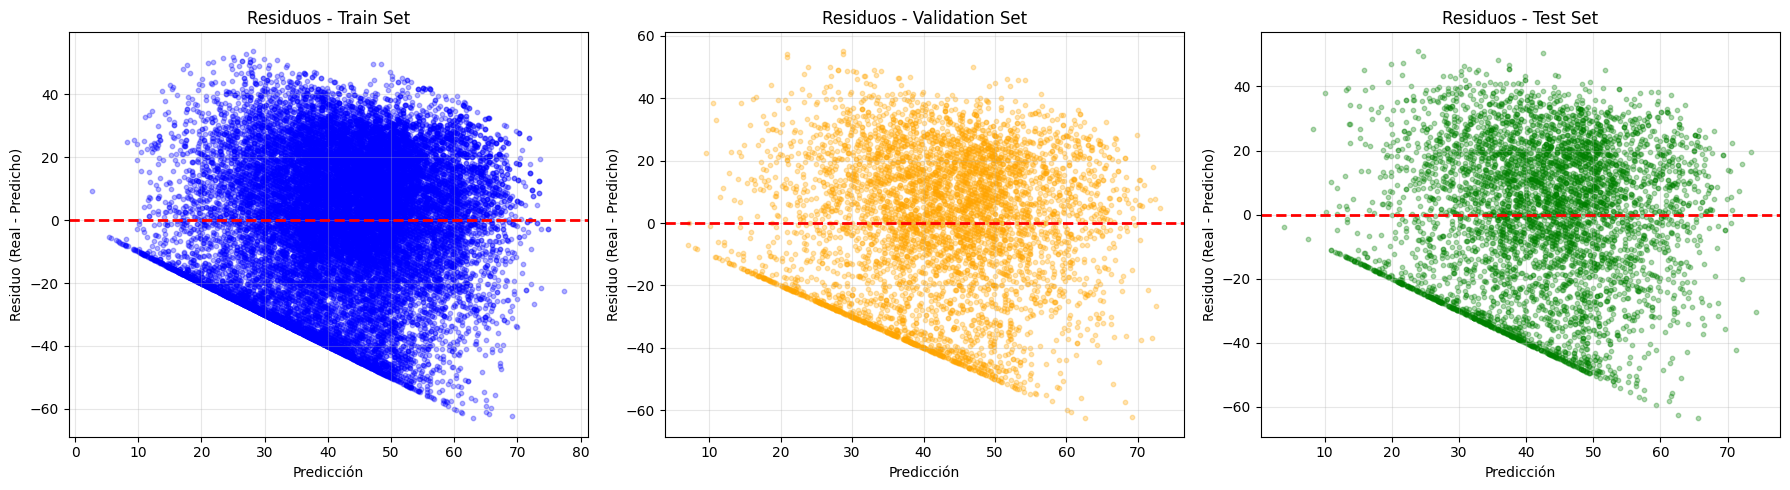


ANÁLISIS DE RESIDUOS
Residuo medio Train: -0.1329
Residuo medio Val:   0.2041
Residuo medio Test:  0.0271

✅ Si los residuos están centrados en 0 sin patrón, el modelo no tiene sesgo.


In [12]:
# ============================================
#  ANÁLISIS DE RESIDUOS (VALIDACIÓN ADICIONAL)
# ============================================

residuals_train = y_train - y_train_pred
residuals_val = y_val - y_val_pred
residuals_test = y_test - y_test_pred

plt.figure(figsize=(18, 5))

# Residuos Train
plt.subplot(1, 3, 1)
plt.scatter(y_train_pred, residuals_train, alpha=0.3, s=10, color='blue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicción')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Residuos - Train Set')
plt.grid(True, alpha=0.3)

# Residuos Validation
plt.subplot(1, 3, 2)
plt.scatter(y_val_pred, residuals_val, alpha=0.3, s=10, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicción')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Residuos - Validation Set')
plt.grid(True, alpha=0.3)

# Residuos Test
plt.subplot(1, 3, 3)
plt.scatter(y_test_pred, residuals_test, alpha=0.3, s=10, color='green')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicción')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Residuos - Test Set')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_residuos.png', dpi=300)
plt.show()

# Interpretación de residuos
print("\n" + "="*70)
print("ANÁLISIS DE RESIDUOS")
print("="*70)
print(f"Residuo medio Train: {residuals_train.mean():.4f}")
print(f"Residuo medio Val:   {residuals_val.mean():.4f}")
print(f"Residuo medio Test:  {residuals_test.mean():.4f}")
print("\n✅ Si los residuos están centrados en 0 sin patrón, el modelo no tiene sesgo.")

In [13]:
# ============================================
#  RESUMEN FINAL Y CONCLUSIONES
# ============================================

print("\n" + "="*70)
print("RESUMEN EJECUTIVO DEL MODELO - SPOTIFY POPULARITY PREDICTOR")
print("="*70)

# 1. Detalles Técnicos de la Red
print(f"\nCONFIGURACIÓN DE LA RED NEURONAL:")
print(f"  - Arquitectura Deep Learning: 128 → 64 → 32 → 1")
print(f"  - Regularización: Dropout (0.3, 0.3, 0.2) + BatchNormalization")
print(f"  - Optimizador: Adam (LR=0.001) con ReduceLROnPlateau")
print(f"  - Total de parámetros entrenados: {model.count_params():,}")

# 2. Desempeño Final (Test Set)
print(f"\nRESULTADOS FINALES (DATOS NO VISTOS):")
print(f"  - MAE (Error Medio): {test_metrics['mae']:.4f} puntos")
print(f"  - RMSE:              {test_metrics['rmse']:.4f}")
print(f"  - R² (Puntuación):   {test_metrics['r2']:.4f}")

# 3. Diagnóstico de Generalización
print(f"\nVALIDACIÓN DE ROBUSTEZ:")
# Comparamos Test contra Validación para asegurar que el modelo es estable
if test_metrics['mae'] < val_metrics['mae'] * 1.15:
    print(f"  ✅ ESTADO: El modelo generaliza correctamente (Test MAE estable).")
else:
    print(f"  ⚠️ ESTADO: Ligera desviación en Test. Revisar representatividad de los datos.")

# 4. Inventario de Entregables
print(f"\nARCHIVOS Y RECURSOS GENERADOS:")
print(f"  - Modelo exportado:     mejor_modelo_spotify.keras")
print(f"  - Gráfica Entrenamiento: overfitting_validation.png")
print(f"  - Gráfica Predicciones: comparativa_predicciones.png")
print(f"  - Gráfica Residuos:     analisis_residuos.png")

print("\n" + "="*70)
print("FIN DEL PROCESO - LISTO PARA ENTREGA")
print("="*70)


RESUMEN EJECUTIVO DEL MODELO - SPOTIFY POPULARITY PREDICTOR

CONFIGURACIÓN DE LA RED NEURONAL:
  - Arquitectura Deep Learning: 128 → 64 → 32 → 1
  - Regularización: Dropout (0.3, 0.3, 0.2) + BatchNormalization
  - Optimizador: Adam (LR=0.001) con ReduceLROnPlateau
  - Total de parámetros entrenados: 13,825

RESULTADOS FINALES (DATOS NO VISTOS):
  - MAE (Error Medio): 18.4523 puntos
  - RMSE:              22.1437
  - R² (Puntuación):   0.1977

VALIDACIÓN DE ROBUSTEZ:
  ✅ ESTADO: El modelo generaliza correctamente (Test MAE estable).

ARCHIVOS Y RECURSOS GENERADOS:
  - Modelo exportado:     mejor_modelo_spotify.keras
  - Gráfica Entrenamiento: overfitting_validation.png
  - Gráfica Predicciones: comparativa_predicciones.png
  - Gráfica Residuos:     analisis_residuos.png

FIN DEL PROCESO - LISTO PARA ENTREGA
